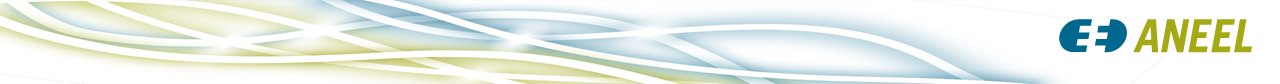
1. As entradas são:

    1.1 Relatórios de receita de venda 13 e 17 de 2020 e 2021 já agrupados: ./Inputs/RV013.xlsx e ./Inputs/RV017.xlsx
    
    1.2 Relatório com nome, CEG e CNPJ das usinas: ./Inputs/RelatorioEmpreendimentoCEG_CNPJ.xlsx.
    
    1.3 Relatório com nome, CEG e CNPJ das usinas cujos nomes não encontram correspodência no relatório do item 1.2: ./Inputs/Faltantes.xlsx
    
    
2. A saída é um arquivo Excel ./Inputs/P_BI_base.xlsx com as seguintes abas:

    2.1 Tabela Dimensão RV : Tabela dimensão para ambos RRVs com nomes, IDs, CEGs, tipos de geração, UFs e CNPJs de cada usina. O CNPJ é àquele que está presente no relatório do item 1.2.
    
    2.2 Tabela Fato com ambos RRVs: Tabela com os dois RRVs contendo a receita para todos os meses de 2020 e 2021 para todas as usinas.
    
    2.3 Datas: Tabela com todas as datas de 2020 a 2021.
    
    2.4 RV_13_CCEE e RV_17_CCEE: Tabela com as mesmas informações da tabela mencionada no item 1.1, porém com o ID de cada Usina identificado.

In [1]:
# Importa bibliotecas
import pandas as pd
from datetime import date
import numpy as np
import pickle

In [2]:
# Parâmetros de coluna
colunas_rv_dim = ['USINA'] # Colunas necessárias para criação da tabela dimensão
colunas_rv_fact = ['USINA',"DATA","RECEITA DE VENDA MENSAL (R$)"] # Colunas necessárias para criação da tabela fato


# Dicionários para renomear colunas
dict_colunas_rv_13 = {
                      "EMPREENDIMENTO":"USINA",
                      'RECEITA DE VENDA MENSAL (R$)':"RECEITA DE VENDA MENSAL (R$)"}

dict_colunas_rv_17 = {
                      "EMPREENDIMENTO":"USINA",
                      'TOTAL DA RECEITA DE VENDA (R$)':"RECEITA DE VENDA MENSAL (R$)"}


In [3]:
# Valida CNPJ 
def validar_cnpj(s: pd.Series): 
    digitos = s.str.extract(r'(\d)(\d).(\d)(\d)(\d).(\d)(\d)(\d)/(\d)(\d)(\d)(\d)-').astype(np.uint8)
    dv = s.str.extract(r'-(\d)(\d)').astype(np.uint8)
    dig_1 = np.array([6,7,8,9,2,3,4,5,6,7,8,9 ],dtype=np.uint8)
    mult1 = np.sum(np.multiply(digitos,dig_1),axis=1).astype(np.uint16)
    res1 = np.remainder(mult1,11).astype(np.uint8)
    res1[res1==10] = 0
    digitos =  pd.concat([digitos,res1],axis=1)
    dig_2 = np.array([5,6,7,8,9,2,3,4,5,6,7,8,9],dtype=np.uint8)
    mult2 = np.sum(np.multiply(digitos,dig_2),axis=1).astype(np.uint16)
    res2 = np.remainder(mult2,11).astype(np.uint8)
    res2[res2==10] = 0
    digitos =  pd.concat([digitos,res2],axis=1)
    return ((dv[0] - res1) == 0) & ((dv[1] - res2) == 0)

# Formata CNPJ
def formatar_cnpj(s: pd.Series, check_val =False,on_error = "pass"): 
    s= s.apply(str).str.strip() # Transforma CPJS em string
    s.replace(to_replace="\W", value=r"", regex=True,inplace=True)
    s = s.str.pad(14,"left","0")  # Faz padding left com zeros
    s.replace(to_replace="(\d{2})(\d{3})(\d{3})(\d{4})(\d{2})", value=r"\1.\2.\3/\4-\5", regex=True,inplace=True)
    
    if check_val or on_error == "raise":
        invalidos  = ~validar_cnpj(s)
        quant_errors = invalidos.count()
        print(f"{quant_errors} CNPJs inválidos:")
        display(s[invalidos])
    if on_error == "raise" and quant_errors > 0:
        raise 
    
    return s

# Normaliza nomes retirando caracteres não ascii
def normalizar_str(s: pd.Series,no_spaces = False):
    s = s.str.strip().str.upper()
    s  = s.str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
    if no_spaces:
        s = s.replace(to_replace=r"\s{1,}", value=r"", regex=True)
    else:
        s = s.replace(to_replace=r"\s{1,}", value=r" ", regex=True)      
    return s

# Formata CEG
def formatar_ceg(s: pd.Series):
    s = s.str.strip().str.upper()
    s.replace(to_replace="\W", value=r"", regex=True,inplace=True)
    s = s.str.replace(r"(\w{3})(\w{2})(\w{2})(\d{6})(\d{1})",r"\1.\2.\3.\4-\5",regex=True)
    return s

# Extrai as seguintes informações a partir do CEG: "Geração","Fonte","UF","ID","DV"
def extrair_info_ceg(s: pd.Series):
    ceg_info = s.str.extract("(\w{3}).(\w{2}).(\w{2}).(\d{6})-(\d{1})")
    ceg_info.columns = ["Geração","Fonte","UF","ID","DV"]
    ceg_info["ID"] = ceg_info["ID"].astype(int) 
    return ceg_info


def normalizar_nome_ccee(USINA : pd.Series):
    USINA = normalizar_str(USINA)
    USINA = USINA.str.replace('AHE ', '')
    USINA = USINA.str.replace('UHE ', '')
    USINA = USINA.str.replace('EOL ', '')
    USINA = USINA.str.replace('PCH ', '')
    USINA = USINA.str.replace('UTE ', '')
    USINA = USINA.str.strip().replace(to_replace=r"\s{1,}", value=r"", regex=True)
    return USINA

# Junta dicionário. Retorna erro caso haja valores distintos para uma mesma chave.
def merge_dict(dict_a,dict_b,stop_first=False):
    keys = list(dict.fromkeys((*dict_a,*dict_b)))
    erros = erros = {"dict_a":[],"dict_b":[]}
    index = []
    for key in keys:
        if (key in dict_a) and (key in dict_b):
            if dict_a[key] != dict_b[key]:
                if stop_first:
                    raise Exception(f" dict_a[{key}] = {dict_a[key]} and dict_b[{key}] = {dict_b[key]}")
                else:
                    erros["dict_a"].append(dict_a[key])
                    erros["dict_b"].append(dict_b[key])
                    index.append(key)
    if len(erros["dict_a"] + erros["dict_b"]) > 1:
        print("Diferenças encontradas:")
        display(pd.DataFrame(erros,index=index))
        raise Exception(f"Valores distintos para uma mesma chave.")
    return {**dict_a,**dict_b}

## Tratando dados dos RRVs

In [4]:
# O trecho comentado abaixo converte arquivo Excel em .parquet para leitura do arquivo mais rápida.
# O formato parquet é suportado pelo Power BI

#rv_13 = pd.read_excel("./Inputs/RV013.xlsx")
#rv_17 = pd.read_excel("./Inputs/RV017.xlsx")

"""
rv_13["CNPJ COMPRADOR"] = rv_13["CNPJ COMPRADOR"].astype(str)
rv_13["CNPJ VENDEDOR"] = rv_13["CNPJ VENDEDOR"].astype(str)
rv_13.to_parquet("./Inputs/RV013.gzip")
rv_17["CNPJ COMPRADOR"] = rv_17["CNPJ COMPRADOR"].astype(str)
rv_17["CNPJ VENDEDOR"] = rv_17["CNPJ VENDEDOR"].astype(str)
rv_17.to_parquet("./Inputs/RV017.gzip")
"""

rv_13 = pd.read_parquet("./Inputs/RV013.gzip")
rv_17 = pd.read_parquet("./Inputs/RV017.gzip")


rv_17.rename(columns= dict_colunas_rv_17,inplace= True)
rv_13.rename(columns= dict_colunas_rv_13,inplace= True)


rv_17.dropna(how="all",inplace = True) # Exclui linhas que possuam dados vazios
rv_13.dropna(how="all",inplace = True) # Exclui linhas que possuam dados vazios

# Formata CNPJs
rv_17["CNPJ VENDEDOR"]= formatar_cnpj(rv_17["CNPJ VENDEDOR"])
rv_13["CNPJ VENDEDOR"]= formatar_cnpj(rv_13["CNPJ VENDEDOR"])

rv_17["CNPJ COMPRADOR"]= formatar_cnpj(rv_17["CNPJ COMPRADOR"])
rv_13["CNPJ COMPRADOR"]= formatar_cnpj(rv_13["CNPJ COMPRADOR"])

rv_17_copy = rv_17.copy(deep=True)  # Cria cópia do dataframe com dados originais
rv_13_copy = rv_13.copy(deep=True)  


temp = rv_13["USINA"].copy(deep=True) # Variável temporária para criar dicionário
rv_13["USINA"] = normalizar_nome_ccee(rv_13["USINA"]) # Normaliza nomes das USINAs
dict_nome_USINA_13 = dict(zip(temp,rv_13["USINA"]))   # Dicionário nomes originais : nomes normalizados
temp = rv_17["USINA"].copy(deep=True)                 # Variável temporária para criar dicionário
rv_17["USINA"] = normalizar_nome_ccee(rv_17["USINA"]) # Normaliza nomes das USINAs
dict_nome_USINA_17 = dict(zip(temp,rv_17["USINA"]))   # Dicionário nomes originais : nomes normalizados
dict_nome_USINA = merge_dict(dict_nome_USINA_13,dict_nome_USINA_17)  #Junta dicionário nomes originais : nomes normalizados

# Separa rv_13 em dataframes dim e fact
rv_13_dim= rv_13[colunas_rv_dim].drop_duplicates(subset = ['USINA'], keep='first')
rv_13_fact = rv_13[colunas_rv_fact].copy(deep=True)
# Separa rv_17 em dataframes dim e fact
rv_17_dim= rv_17[colunas_rv_dim].drop_duplicates(subset = ['USINA'], keep='first')
rv_17_fact = rv_17[colunas_rv_fact].copy(deep=True)

# Ordena alfabeticamente dataframes
rv_13_dim = rv_13_dim.sort_values('USINA',ignore_index=True)
rv_13_fact = rv_13_fact.sort_values('USINA',ignore_index=True)
rv_17_dim = rv_17_dim.sort_values('USINA',ignore_index=True)
rv_17_fact = rv_17_fact.sort_values('USINA',ignore_index=True)

## Relatório de USINA / CEG / CNPJ

In [5]:
relatorio_ceg_cnpj = pd.read_excel("./Inputs/RelatorioEmpreendimentoCEG_CNPJ.xlsx")[['NumCnpj','CodCEG','NomEmpreendimento']]
relatorio_ceg_cnpj.columns = ['CNPJ','CEG','USINA'] # Renomeia colunas
# Remove linhas com numero de CEG e USINA iguais
relatorio_ceg_cnpj = relatorio_ceg_cnpj.drop_duplicates(keep="first").dropna(subset=["CEG","USINA"])
relatorio_ceg_cnpj["CNPJ"] = formatar_cnpj(relatorio_ceg_cnpj["CNPJ"]) # Formata CNPJ
relatorio_ceg_cnpj["CEG"] = formatar_ceg(relatorio_ceg_cnpj["CEG"])  # Formata CEG
relatorio_ceg_cnpj["ID"] = extrair_info_ceg(relatorio_ceg_cnpj["CEG"])["ID"] # Extrai ID do CEG
#relatorio_ceg_cnpj['USINA'] = normalizar_str(relatorio_ceg_cnpj['USINA'],no_spaces=False) # Normaliza nomes
dict_USINA_id_com_space_relatorio = dict(zip(relatorio_ceg_cnpj.ID, relatorio_ceg_cnpj.USINA)) # Dicionário nome : id
relatorio_ceg_cnpj['USINA'] = normalizar_str(relatorio_ceg_cnpj['USINA'],no_spaces=True) # Remove espaços
relatorio_ceg_cnpj = relatorio_ceg_cnpj.sort_values('USINA') # Ordena dataframe

# Criação de dicionários
dict_id_ceg = dict(zip(relatorio_ceg_cnpj.ID,relatorio_ceg_cnpj.CEG)) # Dicionário id : ceg
dict_USINA_id = dict(zip(relatorio_ceg_cnpj.USINA, relatorio_ceg_cnpj.ID)) # Dicionário nome : id
dict_id_USINA = dict(zip(relatorio_ceg_cnpj.ID, relatorio_ceg_cnpj.USINA)) # Dicionário id : nome
dict_id_cnpj = dict(zip(relatorio_ceg_cnpj.ID, relatorio_ceg_cnpj.CNPJ)) # # Dicionário id : CNPJ
relatorio_ceg_cnpj.head()

,CNPJ,CEG,USINA,ID
1,04.237.975/0001-99,UHE.PH.RS.000012-4,14DEJULHO,12
2,06.538.308/0001-71,UTE.PE.SC.029920-0,29DEOUTUBRO,29920
4,23.640.204/0001-92,UTE.PE.MG.032686-0,300KVASCANIA,32686
5,45.985.371/0001-08,UTE.PE.SP.028642-7,3MITAPETININGA,28642
6,45.985.371/0001-08,UTE.PE.SP.028919-1,3MSUMARE,28919


In [6]:
rv_13_dim['ID'] = rv_13_dim['USINA'].map(dict_USINA_id)  # Associa nome ao ID na tabela dimensão
rv_17_dim['ID'] = rv_17_dim['USINA'].map(dict_USINA_id)

print(f"{rv_13_dim.ID.isnull().sum()} USINAs não identificadas no relatório RV_13.")
print(f"{rv_17_dim.ID.isnull().sum()} USINAs não identificadas no relatório RV_17.")

89 USINAs não identificadas no relatório RV_13.
90 USINAs não identificadas no relatório RV_17.


## Carregamento de planilha com USINAs cujo CEG não foi identificado

In [7]:
non_ident = pd.read_excel("./Inputs/Faltantes.xlsx") # Carrega arquivo com nomes não identificados
non_ident = non_ident.dropna(subset=["CEG"])

# Dicionário USINA : ID com USINAs não identificadas
dict_faltantes_usina_id = dict(zip(
    non_ident["Usina"],
    non_ident["CEG"].astype(int)
))


# Juntando dicionários
dict_USINA_id =  merge_dict(dict_faltantes_usina_id,dict_USINA_id)

# Associa ID a USINA com os valores faltantes
rv_13_dim['ID'] = rv_13_dim['USINA'].map(dict_USINA_id)
rv_17_dim['ID'] = rv_17_dim['USINA'].map(dict_USINA_id)

# Remove linhas com ID iguais
rv_13_dim = rv_13_dim.drop_duplicates(subset=["ID"])
rv_17_dim = rv_17_dim.drop_duplicates(subset=["ID"])

# Associa ID com nome
rv_13_fact["ID"] = rv_13_fact["USINA"].map(dict_USINA_id)
rv_17_fact["ID"] = rv_17_fact["USINA"].map(dict_USINA_id)

print(f"{rv_13_dim.ID.isnull().sum()} usinas não identificadas no relatório RV_13.")
print(f"{rv_17_dim.ID.isnull().sum()} usinas não identificadas no relatório RV_17.")

display(rv_13_dim.head())
display(rv_17_dim.head())

0 usinas não identificadas no relatório RV_13.
0 usinas não identificadas no relatório RV_17.


,USINA,ID
0,14DEJULHO,12
1,ADOPOPINHAK,31598
3,AGUABRAVA,29045
4,AGUAPRATA,29044
5,AGUAVERMELHAIV,34206


,USINA,ID
0,14DEJULHO,12
1,ADOPOPINHAK,31598
3,AGUABRAVA,29045
4,AGUAPRATA,29044
5,AGUAVERMELHAIV,34206


In [8]:
# Deletar colunas USINA na tabela fato, pois já há ID na tabela como chave primária
del rv_13_fact["USINA"]
del rv_17_fact["USINA"]

In [9]:
# Coloca nomes corretos na tabela Dimensão
rv_13_dim["USINA"] = rv_13_dim["ID"].map(dict_USINA_id_com_space_relatorio)
rv_17_dim["USINA"] = rv_17_dim["ID"].map(dict_USINA_id_com_space_relatorio)

print(f"{rv_13_dim.ID.isnull().sum()} usinas não identificadas no relatório RV_13.")
print(f"{rv_17_dim.ID.isnull().sum()} usinas não identificadas no relatório RV_17.")
display(rv_13_dim.sample(5))
display(rv_17_dim.sample(5))

0 usinas não identificadas no relatório RV_13.
0 usinas não identificadas no relatório RV_17.


,USINA,ID
523,Ventos de Campo Formoso II,31010
121,Campo Largo VII,33632
12,Aparecida,35736
63,Baixa do Feijão II,30933
573,Ventos de Vila Paraíba II (Antiga Vila Paraíba...,36985


,USINA,ID
13,Aparecida Parte I,27250
580,Vista Alegre II,31702
206,Fortuna II,28426
187,Dreen São Bento do Norte,30536
156,Coxilha Seca,31487


In [10]:
# Adiciona CEG na tabela dimensão
rv_13_dim["CEG"] = rv_13_dim["ID"].map(dict_id_ceg)
rv_17_dim["CEG"] = rv_17_dim["ID"].map(dict_id_ceg)
display(rv_17_dim.sample(5))

,USINA,ID,CEG
90,Borgo,30837,EOL.CV.BA.030837-4
32,Aura Lagoa do Barro 01,33621,EOL.CV.PI.033621-1
305,MC2 Nova Venécia 2,30196,UTE.GN.MA.030196-5
371,Porto Primavera (Eng° Sérgio Motta),2127,UHE.PH.SP.002127-0
571,Viana,29664,UTE.PE.ES.029664-3


In [11]:
# Adiciona colunas |Geração|UF| nas tabelas dimensão
rv_13_dim = pd.concat([rv_13_dim,extrair_info_ceg(rv_13_dim["CEG"])[["Geração","UF"]]],axis=1) 
rv_17_dim = pd.concat([rv_17_dim,extrair_info_ceg(rv_17_dim["CEG"])[["Geração","UF"]]],axis=1)
# Adiciona CNPJ conforme relatório nas tabelas dimensão
rv_13_dim["CNPJ"] = rv_13_dim["ID"].map(dict_id_cnpj)
rv_17_dim["CNPJ"] = rv_17_dim["ID"].map(dict_id_cnpj)
display(rv_13_dim.sample(5))
display(rv_17_dim.sample(5))

,USINA,ID,CEG,Geração,UF,CNPJ
543,Ventos de Santo Estevão V,31764,EOL.CV.PE.031764-0,EOL,PE,15.674.805/0001-98
421,Santana II,49990,UTE.PE.AP.049990-0,UTE,AP,00.357.038/0001-16
324,Ouro Verde,32012,EOL.CV.CE.032012-9,EOL,CE,16.849.271/0001-56
468,Sertão Solar Barreiras II,33470,UFV.RS.BA.033470-7,UFV,BA,29.958.296/0001-30
97,Cabeço Vermelho II,31665,EOL.CV.RN.031665-2,EOL,RN,20.024.516/0001-83


,USINA,ID,CEG,Geração,UF,CNPJ
564,Ventos do Morro do Chapéu,30582,EOL.CV.CE.030582-0,EOL,CE,12.774.017/0001-85
354,Pito,30794,CGH.PH.SC.030794-7,CGH,SC,12.979.342/0001-84
234,Iaco Agrícola,30269,UTE.AI.MS.030269-4,UTE,MS,07.895.728/0001-78
51,Aura Queimada Nova 03,33625,EOL.CV.PI.033625-4,EOL,PI,21.959.361/0001-30
231,Guarani Tanabi 2,31445,UTE.AI.SP.031445-5,UTE,SP,47.080.619/0001-17


In [12]:
rv_dim = pd.concat([rv_13_dim,rv_17_dim],axis=0).drop_duplicates() # Unifica tabelas dimensão 

In [13]:
# Junta registros com mesmo ID e mês
rv_13_fact_group = rv_13_fact.groupby(["ID","DATA"])                                                        
rv_17_fact_group = rv_17_fact.groupby(["ID","DATA"]) 

In [14]:
# Cálcula renda mensal por ID
rv_13_fact_agg = rv_13_fact_group.agg(
    Receita_Mensal = ("RECEITA DE VENDA MENSAL (R$)","sum")).reset_index()
rv_17_fact_agg = rv_17_fact_group.agg(
    Receita_Mensal = ("RECEITA DE VENDA MENSAL (R$)","sum")).reset_index()

In [15]:
# Junta tabelas de renda mensal por ID dos dois relatórios em um dataframe
fact_merged = pd.merge(
    rv_13_fact_agg,
    rv_17_fact_agg,
    on=["DATA","ID"],
    how = "outer",
    suffixes=["_RV_13","_RV_17"]
)

In [16]:
# Cria dataframe com coluna contendo todas as datas que estejam em ambos relatórios.
intervalo_datas = [max(rv_13_fact["DATA"].min(),rv_17_fact["DATA"].min()),min(rv_13_fact["DATA"].max(),rv_17_fact["DATA"].max())]
# Não usar Série para poder usar método .assign
datas =  pd.DataFrame(
    pd.Series(        
            pd.date_range(
            min(intervalo_datas),
            max(intervalo_datas),
            freq="MS"),
    name="DATA")
)

# DF com todos IDs
ids =  pd.DataFrame(
    pd.Series(
        rv_dim["ID"].unique(),
    name="ID")
)

# Dataframe com todas as datas para plotagem correta dos dados
fact_merged_all_dates = pd.merge(datas.assign(key='x'), ids.assign(key='x'), on='key').drop(labels='key',axis= 1)
fact_merged_all_dates = fact_merged_all_dates.merge(fact_merged,how="outer",on=["ID","DATA"]).fillna(0)

In [17]:
"""# Altera formato das datas para identicação correta das datas no power BI
fact_merged_all_dates['DATA'] = fact_merged_all_dates['DATA'].dt.strftime('%d-%m-%Y')
datas['DATA'] = datas['DATA'].dt.strftime('%d-%m-%Y')"""

"# Altera formato das datas para identicação correta das datas no power BI\nfact_merged_all_dates['DATA'] = fact_merged_all_dates['DATA'].dt.strftime('%d-%m-%Y')\ndatas['DATA'] = datas['DATA'].dt.strftime('%d-%m-%Y')"

In [18]:
# Correções nas cópias
del rv_13_copy["Unnamed: 0"]
del rv_17_copy["Unnamed: 0"]
"""rv_13_copy['DATA'] = rv_13_copy['DATA'].dt.strftime('%d-%m-%Y')
rv_17_copy['DATA'] = rv_17_copy['DATA'].dt.strftime('%d-%m-%Y')"""
rv_13_copy["ID"] = rv_13_copy["USINA"].map(dict_nome_USINA).map(dict_USINA_id)
rv_17_copy["ID"] = rv_17_copy["USINA"].map(dict_nome_USINA).map(dict_USINA_id)

## Verificações

In [19]:
# Verifica se a soma total das rendas são iguais
print(fact_merged_all_dates["Receita_Mensal_RV_13"].sum() - rv_13_fact["RECEITA DE VENDA MENSAL (R$)"].sum())
print(fact_merged_all_dates["Receita_Mensal_RV_17"].sum() - rv_17_fact["RECEITA DE VENDA MENSAL (R$)"].sum())

1.52587890625e-05
-1.52587890625e-05


In [20]:
# Checa se há diferença nas somas do rendimento mensal entre tabelas rv_xx_fact e fact_merged_all_dates
max_diff = 1e-5 # Tolerância da comparação 
diff_13 = ids.ID.apply(lambda id : rv_13_fact["RECEITA DE VENDA MENSAL (R$)"][rv_13_fact.ID == id].sum()  
         - fact_merged_all_dates.Receita_Mensal_RV_13[fact_merged_all_dates.ID == id].sum())
display(diff_13[diff_13>max_diff])
diff_17 = ids.ID.apply(lambda id : rv_17_fact["RECEITA DE VENDA MENSAL (R$)"][rv_17_fact.ID == id].sum()  
         - fact_merged_all_dates.Receita_Mensal_RV_17[fact_merged_all_dates.ID == id].sum())
display(diff_17[diff_17>max_diff])

Series([], Name: ID, dtype: float64)

Series([], Name: ID, dtype: float64)

In [21]:
# Checa se há diferença nas somas do rendimento mensal entre tabelas rv_xx_copy e fact_merged_all_dates
max_diff = 1e-5 # Tolerância da comparação 
diff_13 = ids.ID.apply(lambda id : rv_13_copy["RECEITA DE VENDA MENSAL (R$)"][rv_13_copy.ID == id].sum()  
         - fact_merged_all_dates.Receita_Mensal_RV_13[fact_merged_all_dates.ID == id].sum())
display(diff_13[diff_13>max_diff])
diff_17 = ids.ID.apply(lambda id : rv_17_copy["RECEITA DE VENDA MENSAL (R$)"][rv_17_copy.ID == id].sum()  
         - fact_merged_all_dates.Receita_Mensal_RV_17[fact_merged_all_dates.ID == id].sum())
display(diff_17[diff_17>max_diff])

Series([], Name: ID, dtype: float64)

Series([], Name: ID, dtype: float64)

In [22]:
# Encontra quais USINAs estão no RV_13 não estão no RV_17
rv_17_dim[~rv_17_dim["ID"].isin(rv_13_dim["ID"])]

,USINA,ID,CEG,Geração,UF,CNPJ
142,Paranoá,1975,PCH.PH.DF.001975-5,PCH,DF,04.232.314/0001-70


In [23]:
# Encontra quais USINAs estão no RV_17 não estão no RV_13
rv_13_dim[~rv_13_dim["ID"].isin(rv_17_dim["ID"])]

,USINA,ID,CEG,Geração,UF,CNPJ


In [24]:
# Conta valores nulos na tabela fato RV_17
print(rv_17_fact.isnull().sum())
# Conta valores nulos na tabela fato RV_13
print(rv_13_fact.isnull().sum())
# Conta valores nulos na dimensão fato RV_13
print(rv_13_dim.isnull().sum())
# Conta valores nulos na dimensão fato RV_17
print(rv_17_dim.isnull().sum())
# Conta valores nulos nas tabelas cópia
print(rv_13_copy.isnull().sum())
print(rv_17_copy.isnull().sum())

DATA                            0
RECEITA DE VENDA MENSAL (R$)    0
ID                              0
dtype: int64
DATA                            0
RECEITA DE VENDA MENSAL (R$)    0
ID                              0
dtype: int64
USINA      0
ID         0
CEG        0
Geração    0
UF         0
CNPJ       0
dtype: int64
USINA      0
ID         0
CEG        0
Geração    0
UF         0
CNPJ       0
dtype: int64
DATA                            0
USINA                           0
COMPRADOR                       0
CNPJ COMPRADOR                  0
VENDEDOR                        0
CNPJ VENDEDOR                   0
RECEITA DE VENDA MENSAL (R$)    0
ID                              0
dtype: int64
DATA                            0
USINA                           0
COMPRADOR                       0
CNPJ COMPRADOR                  0
VENDEDOR                        0
CNPJ VENDEDOR                   0
RECEITA DE VENDA MENSAL (R$)    0
ID                              0
dtype: int64


In [25]:
# Coloca colunas da tabelas cópia em upper case
rv_13_copy.columns = rv_13_copy.columns.str.upper()
rv_17_copy.columns = rv_17_copy.columns.str.upper()
rv_13_copy = rv_13_copy[["ID","DATA","USINA","CNPJ VENDEDOR","RECEITA DE VENDA MENSAL (R$)"]]
rv_17_copy = rv_17_copy[["ID","DATA","USINA","CNPJ VENDEDOR","RECEITA DE VENDA MENSAL (R$)"]]

In [39]:
fact_merged_all_dates.Receita_Mensal_RV_13[(fact_merged_all_dates.DATA >= pd.Timestamp(2020,3,1)) & (fact_merged_all_dates.ID == 31698)].sum()

35460038.38

In [28]:
# Salva dataframes em arquivo excel
with pd.ExcelWriter('./Outputs/P_BI_base.xlsx',datetime_format="DD/MM/YYYY") as writer:  
    rv_dim.to_excel(writer,sheet_name='Tabela Dimensão RV',index=False)
    fact_merged_all_dates.to_excel(writer,sheet_name='Tabela Fato com ambos RRVs',index=False)
    datas.to_excel(writer,sheet_name='Datas',index=False)
    rv_13_copy.to_excel(writer,sheet_name='RV_13_CCEE',index=False)
    rv_17_copy.to_excel(writer,sheet_name='RV_17_CCEE',index=False)